In [1]:
# ================================================
# Notebook 3: Handwriting Recognition (Final Improved Version)
# EasyOCR + Strong Preprocessing + Line Segmentation + Medicine Spell Correction
# ================================================

print("🔤 Notebook 3: Final Improved EasyOCR Version Started")

🔤 Notebook 3: Final Improved EasyOCR Version Started


In [2]:
# Install Required Packages
# Cell 2: Install packages
!pip install easyocr pyspellchecker --quiet

print("✅ EasyOCR and spell checker installed")

✅ EasyOCR and spell checker installed


In [3]:
# Imports
# Cell 3: Imports
import easyocr
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from spellchecker import SpellChecker
import os

print("✅ All libraries imported")
print(f"GPU Available: {torch.cuda.is_available()}")

✅ All libraries imported
GPU Available: True


In [4]:
# Strong Preprocessing Function
# Cell 4: Strong Preprocessing for Messy Prescriptions
def preprocess_handwriting(image_path, show_steps=False):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)
    
    # Sharpening
    sharpened = cv2.addWeighted(enhanced, 2.5, cv2.GaussianBlur(enhanced, (0,0), 3), -1.5, 0)
    
    # Binary threshold
    thresh = cv2.adaptiveThreshold(sharpened, 255, 
                                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 11, 2)
    
    kernel = np.ones((2,2), np.uint8)
    final = cv2.dilate(thresh, kernel, iterations=1)
    
    final_pil = Image.fromarray(cv2.cvtColor(final, cv2.COLOR_GRAY2RGB))
    
    print(f"✅ Strong preprocessing applied to {os.path.basename(image_path)}")
    return final_pil, final

In [5]:
# Initialize EasyOCR
# Cell 5: Initialize EasyOCR
print("⏳ Loading EasyOCR models... (First time may take 30-60 seconds)")

reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

print("✅ EasyOCR Reader initialized successfully!")

⏳ Loading EasyOCR models... (First time may take 30-60 seconds)
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✅ EasyOCR Reader initialized successfully!


In [6]:
# Medicine Name spell corrector
# Cell 6: Medicine Name Spell Corrector
spell = SpellChecker()

# Common medicine names dictionary (add more as needed)
medicine_dict = {
    "augmentin": "Augmentin", "amoxicillin": "Amoxicillin", "enzoflam": "Enzoflam",
    "pand": "Pan-D", "hexigel": "Hexigel", "pantop": "Pantop", "dolo": "Dolo",
    "crocin": "Crocin", "azithro": "Azithro", "levoflox": "Levoflox",
    "aftermeals": "after meals", "beforemeals": "before meals"
}

def correct_medicine_name(text):
    words = text.split()
    corrected = []
    for word in words:
        lower = word.lower()
        if lower in medicine_dict:
            corrected.append(medicine_dict[lower])
        else:
            corrected_word = spell.correction(lower)
            corrected.append(corrected_word.capitalize() if corrected_word else word)
    return " ".join(corrected)

In [7]:
# Main Recognition Function (with Line Segmentation)
# Cell 7: Final Recognition Function with Line Segmentation + Spell Correction
def recognize_text(image_path, preprocess=True):
    if isinstance(image_path, str):
        original_cv = cv2.imread(image_path)
        display_img = original_cv.copy()
    else:
        display_img = cv2.cvtColor(np.array(image_path), cv2.COLOR_RGB2BGR)
        original_cv = display_img.copy()
    
    # Preprocessing
    if preprocess:
        print("🛠️ Applying strong preprocessing...")
        _, processed_cv = preprocess_handwriting(image_path, show_steps=False)
        img_to_use = processed_cv
    else:
        img_to_use = original_cv
    
    # Show original image
    plt.figure(figsize=(14, 10))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.title("Original Prescription")
    plt.axis('off')
    plt.show()
    
    print("🤖 Running EasyOCR with Line Segmentation...")
    
    # Run EasyOCR
    result = reader.readtext(img_to_use, detail=1, paragraph=False, 
                             width_ths=0.8, height_ths=0.6, 
                             min_size=10, text_threshold=0.4)
    
    recognized_lines = []
    for detection in result:
        text = detection[1].strip()
        confidence = detection[2]
        if len(text) > 2 and confidence > 0.25:
            corrected_text = correct_medicine_name(text)
            recognized_lines.append(corrected_text)
            print(f"→ {corrected_text:<60} (Conf: {confidence:.3f})")
    
    final_text = "\n".join(recognized_lines)
    
    print("\n" + "="*90)
    print("✅ FINAL RECOGNIZED TEXT:")
    print("="*90)
    print(final_text)
    print("="*90)
    
    return final_text

🛠️ Applying strong preprocessing...
✅ Strong preprocessing applied to 1_3xUyINxRtDf2qowd-kkGQA.jpg


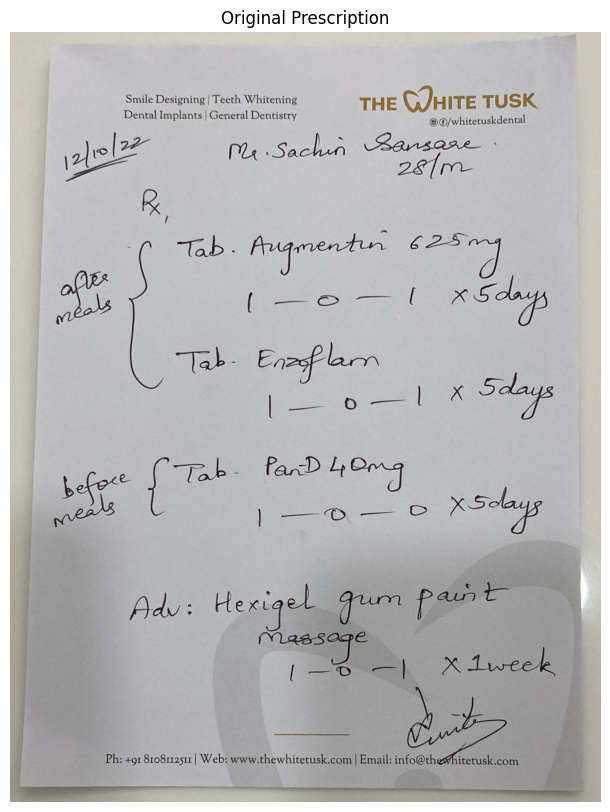

🤖 Running EasyOCR with Line Segmentation...

✅ FINAL RECOGNIZED TEXT:


✅ Result saved to recognized_prescription.txt


In [8]:
# Test your image
# Cell 8: Test on Your Prescription
test_image_path = r"C:\Users\Avilasha\Desktop\handwriting-ocr\input_images\1_3xUyINxRtDf2qowd-kkGQA.jpg"   # ← Change if needed

recognized_text = recognize_text(test_image_path, preprocess=True)

# Save result
with open("recognized_prescription.txt", "w", encoding="utf-8") as f:
    f.write(recognized_text)

print("\n✅ Result saved to recognized_prescription.txt")